**Institución:** Duoc UC   
**Asignatura:** BIY7121 Minería de Datos  
**Autor:** [Eithan Santibañez / Matias Morales]  
**Fecha:** [22 - 04 -2026]  

---
### Objetivo del Notebook
Realizar un proceso de preparación de datos bajo el estándar **CRISP-DM**, enfocándose en el entendimiento de los datos, la auditoría de calidad, el tratamiento de valores atípicos (outliers) y el análisis de correlación lineal. Todo esto fundamentado en las metodologías y buenas prácticas revisadas en clases.

#**Notebook: Análisis y Preprocesamiento de Datos - Conflictos Globales**
Importación de Librerías y Carga de Datos
Justificación:
- Antes de comenzar cualquier análisis, necesitamos importar las herramientas estadísticas y de manipulación de datos en Python.
- Usaremos pandas para manipular el DataFrame, matplotlib y seaborn para la visualización, y scikit-learn para el escalamiento y transformación (encoding). Luego, cargaremos el set de datos proporcionado.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Carga de datos
df = pd.read_csv("global_conflicts_dataset.csv")

# Visualizamos las primeras 5 filas para verificar la carga exitosa
df.head()

,Country_A,Country_B,Conflict_Type,Year,Duration_Days,Military_Deaths_A,Military_Deaths_B,Civilian_Deaths,Economic_Loss_USD_Billions,Temperature_Avg_C,...,Naval_Battles,Sanctions,Refugees_Millions,Ceasefire,Outcome,Latitude,Longitude,Climate_Zone,Resource_Dispute,UN_Involvement
0,France,France,Cold Conflict,2020,1829,33197,41305,50364,176.45,8.2,...,104,Yes,6.68,No,Victory_A,88.811,101.020,Temperate,Land,Yes
1,India,Japan,Cold Conflict,2013,1234,26773,10526,176846,435.83,24.8,...,87,Yes,14.51,Yes,Stalemate,55.878,78.502,Polar,Water,No
2,Israel,USA,Civil War,1970,1982,17256,7604,17280,154.50,17.3,...,9,No,1.63,No,Stalemate,29.263,144.680,Tropical,Water,No
3,Turkey,Australia,Proxy War,2021,1754,1745,33468,92279,273.20,12.3,...,15,No,7.23,No,Victory_A,-22.281,-147.397,Polar,Water,No
4,Australia,France,War,2012,753,29149,40672,72545,351.35,31.1,...,22,Yes,19.65,No,Victory_A,17.638,169.360,Temperate,Land,No


#**Justificación del tratamiento de valores nulos**

**Justificación:**
- la eliminación de registros con valores nulos puede provocar una pérdida significativa de información. Para las variables categóricas como Alliance y Resource_Dispute, se ha optado por una imputación por categoría constante.

- En el caso de las alianzas, la ausencia de un dato se interpreta lógicamente como la inexistencia de un pacto formal ('No Alliance').

- Para las disputas de recursos, ante la falta de certeza, se etiqueta como 'Indeterminated'.
Esto permite mantener la integridad del dataset y permite que el algoritmo de minería de datos trate el "dato faltante" como una categoría informativa en sí misma.


In [ ]:
# Imputación de valores nulos para la variable de alianza
df['Alliance_A'] = df['Alliance_A'].fillna('No Alliance')
df['Alliance_B'] = df['Alliance_B'].fillna('No Alliance')
df['Resource_Dispute'] = df['Resource_Dispute'].fillna('Indeterminated')

print(df[['Alliance_A', 'Alliance_B', 'Resource_Dispute']].isnull().sum())

Alliance_A          0
Alliance_B          0
Resource_Dispute    0
dtype: int64


#**Interpretación:**

- Al ejecutar el conteo de nulos tras la imputación, observamos que las columnas **Alliance_A**, **Alliance_B** y **Resource_Dispute** ahora presentan 0 valores nulos. Esto asegura que, al momento de realizar el Encoding (transformación a números), no se generen errores de ejecución y que todos los conflictos del dataset participen en el análisis de correlación y modelamiento final.


#**Analisis de proporciones**


**Justificación:**
- es vital entender la distribución de las variables objetivo. Usamos un gráfico de torta para verificar si los resultados de los conflictos están balanceados.

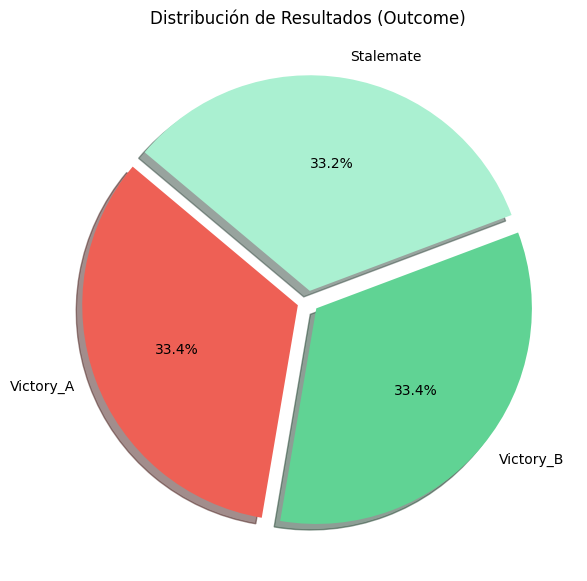

In [ ]:
data_pie = df['Outcome'].value_counts()
colores = ["#EE6055", "#60D394", "#AAF0D1", "#FFD97D", "#FF9B85"]

plt.figure(figsize=(7, 7))
plt.pie(data_pie, labels=data_pie.index, autopct='%1.1f%%', shadow=True, startangle=140, colors=colores, explode=[0.05]*len(data_pie))
plt.title('Distribución de Resultados (Outcome)')
plt.show()

falta interpretacion

#**Funcion de auditoria**



**Justificación:**
- Para garantizar que el modelo no aprenda de datos erróneos, ejecutamos una función de auditoría para detectar nulos y tipos de datos incorrectos

In [ ]:
def auditoria_datos(data):
    observaciones = pd.DataFrame({
        'Columna': data.columns,
        'Tipo': data.dtypes,
        'Nulos': data.isnull().sum(),
        'Nulos %': (data.isnull().sum() / len(data)) * 100,
        'Valores Únicos': data.nunique()
    })
    return observaciones

display(auditoria_datos(df))

# Tratamiento de nulos (Imputación simple para mantener integridad)
df.fillna(method='ffill', inplace=True)

,Columna,Tipo,Nulos,Nulos %,Valores Únicos
Country_A,Country_A,object,0,0.0,15
Country_B,Country_B,object,0,0.0,15
Conflict_Type,Conflict_Type,object,0,0.0,5
Year,Year,int64,0,0.0,75
Duration_Days,Duration_Days,int64,0,0.0,1565
Military_Deaths_A,Military_Deaths_A,int64,0,0.0,2894
Military_Deaths_B,Military_Deaths_B,int64,0,0.0,2908
Civilian_Deaths,Civilian_Deaths,int64,0,0.0,2983
Economic_Loss_USD_Billions,Economic_Loss_USD_Billions,float64,0,0.0,2911
Temperature_Avg_C,Temperature_Avg_C,float64,0,0.0,451


/tmp/ipykernel_1506/4070787817.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


**Interpretación:**
- La tabla de auditoría nos permite mapear rápidamente el estado de salud del dataset. Confirmamos los tipos de datos informáticos (`int64`, `float64` para continuos/discretos, y `object` para categóricos). Además, validamos si existen porcentajes críticos de datos faltantes que debamos abordar en el siguiente paso.

---------------

#**Justificación:**
- realizaremos un mapeo para entender que información contiene cada columna y revisaremos los tipos de datos (numericos o categoricos)

In [ ]:
# Mapeo general e información de los tipos de datos
print("Información del Dataset:")
df.info()

Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country_A                   3000 non-null   object 
 1   Country_B                   3000 non-null   object 
 2   Conflict_Type               3000 non-null   object 
 3   Year                        3000 non-null   int64  
 4   Duration_Days               3000 non-null   int64  
 5   Military_Deaths_A           3000 non-null   int64  
 6   Military_Deaths_B           3000 non-null   int64  
 7   Civilian_Deaths             3000 non-null   int64  
 8   Economic_Loss_USD_Billions  3000 non-null   float64
 9   Temperature_Avg_C           3000 non-null   float64
 10  Rainfall_mm                 3000 non-null   float64
 11  Terrain_Type                3000 non-null   object 
 12  Population_A_Millions       3000 non-null   float64
 13  Populati

In [ ]:
# Separación conceptual de columnas numéricas y categóricas
columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
columnas_categoricas = df.select_dtypes(include=['object']).columns.tolist()

In [ ]:
print("\n--- Mapeo de Variables ---")
print(f"Total variables numéricas ({len(columnas_numericas)}):", columnas_numericas)
print(f"Total variables categóricas ({len(columnas_categoricas)}):", columnas_categoricas)


--- Mapeo de Variables ---
Total variables numéricas (17): ['Year', 'Duration_Days', 'Military_Deaths_A', 'Military_Deaths_B', 'Civilian_Deaths', 'Economic_Loss_USD_Billions', 'Temperature_Avg_C', 'Rainfall_mm', 'Population_A_Millions', 'Population_B_Millions', 'GDP_A_Billions', 'GDP_B_Billions', 'Air_Strikes', 'Naval_Battles', 'Refugees_Millions', 'Latitude', 'Longitude']
Total variables categóricas (13): ['Country_A', 'Country_B', 'Conflict_Type', 'Terrain_Type', 'Alliance_A', 'Alliance_B', 'Weapons_Used', 'Sanctions', 'Ceasefire', 'Outcome', 'Climate_Zone', 'Resource_Dispute', 'UN_Involvement']


In [ ]:
# Estadística descriptiva
df.describe()

,Year,Duration_Days,Military_Deaths_A,Military_Deaths_B,Civilian_Deaths,Economic_Loss_USD_Billions,Temperature_Avg_C,Rainfall_mm,Population_A_Millions,Population_B_Millions,GDP_A_Billions,GDP_B_Billions,Air_Strikes,Naval_Battles,Refugees_Millions,Latitude,Longitude
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1987.338000,1003.734667,24423.385000,24959.623333,100151.649333,253.684450,12.928667,1538.184333,709.784867,697.569867,12329.562933,12439.594433,2489.252000,98.849667,10.082663,-0.146093,0.469165
std,21.766006,568.221869,14129.940099,14345.873994,57927.462774,142.903418,13.094564,862.818221,400.912716,403.902829,7226.239780,7168.683362,1448.823011,58.377493,5.784529,51.958831,103.241034
min,1950.000000,2.000000,105.000000,119.000000,68.000000,0.230000,-10.000000,0.100000,2.600000,1.100000,14.100000,30.900000,0.000000,0.000000,0.000000,-89.992000,-179.903000
25%,1968.000000,529.000000,12292.000000,12768.250000,49719.500000,132.905000,1.700000,796.725000,370.950000,354.100000,6035.450000,6394.050000,1228.750000,47.000000,5.127500,-44.309250,-86.960500
50%,1987.000000,999.000000,23889.000000,24270.000000,100106.500000,257.580000,13.000000,1547.650000,711.300000,699.850000,12388.400000,12357.800000,2457.000000,99.000000,10.155000,-0.413500,-1.689500
75%,2007.000000,1493.000000,36801.000000,37424.500000,149615.750000,374.897500,24.200000,2282.350000,1053.525000,1050.025000,18581.175000,18521.675000,3738.250000,151.000000,15.110000,44.981500,89.974750
max,2024.000000,1999.000000,49995.000000,49992.000000,199972.000000,499.960000,35.000000,2999.000000,1400.000000,1399.700000,24995.200000,24997.500000,4999.000000,199.000000,20.000000,89.989000,179.888000


#**Interpretación:**

- **Tipos de datos:** La función info() nos muestra que tenemos variables enteras (int64, como Year y Duration_Days), de punto flotante (float64, como Economic_Loss_USD_Billions) y cadenas de texto (object, como Conflict_Type y Terrain_Type).
****
- **Mapeo: Hemos identificado** claramente cuáles son los atributos numéricos (que podremos escalar más adelante) y cuáles son los categóricos (que requerirán encoding).
****
- **Estadística Descriptiva:** La función describe() nos entrega las medidas de tendencia central y dispersión. Podemos notar a simple vista las magnitudes variables, por ejemplo, los días de duración frente al PIB (GDP_A_Billions), lo que justifica plenamente la necesidad de realizar un escalamiento posterior para que los algoritmos no den un peso erróneo a las variables más grandes.

#**Limpieza de Datos: Búsqueda de Nulos Justificación:**


**Justificación:**
- Para entender mejor el contexto del negocio (los conflictos), no basta con la estadística descriptiva global. Usaremos funciones de agrupación (`groupby`) para encontrar patrones específicos, analizando el impacto humano y económico según la naturaleza del conflicto (*Conflict_Type*).

Civilian_Deaths         Economic_Loss_USD_Billions        
                         mean     max                       mean     max
Conflict_Type                                                           
Civil War        97563.524288  199502                 256.545276  499.96
Cold Conflict   102337.124150  199370                 257.867857  499.57
Proxy War        97634.937198  199791                 245.845894  498.26
Skirmish        101787.700159  199972                 254.649888  499.09
War             101557.514991  199405                 253.851393  499.47

/tmp/ipykernel_1506/2705101174.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Conflict_Type', y='Civilian_Deaths', palette='viridis')


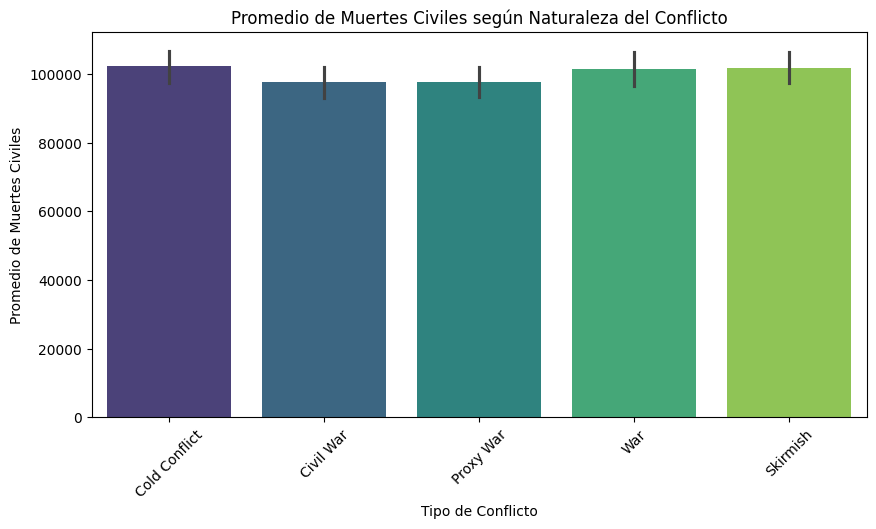

In [ ]:
# Agrupación de datos para análisis focalizado
analisis_agrupado = df.groupby('Conflict_Type')[['Civilian_Deaths', 'Economic_Loss_USD_Billions']].agg(['mean', 'max'])
display(analisis_agrupado)

# Visualización del análisis
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Conflict_Type', y='Civilian_Deaths', palette='viridis')
plt.title('Promedio de Muertes Civiles según Naturaleza del Conflicto')
plt.xticks(rotation=45)
plt.ylabel('Promedio de Muertes Civiles')
plt.xlabel('Tipo de Conflicto')
plt.show()

#**Interpretación:**
- Mediante la tabla agrupada y el gráfico de barras, identificamos qué tipos de conflictos generan mayor daño colateral promedio (muertes civiles) y mayores pérdidas económicas. Esto nos da un indicio temprano de qué variables categóricas podrían tener más peso predictivo si construyéramos un modelo de Machine Learning a futuro.

****

#**Limpieza de Datos: Detección y Tratamiento de Outliers**
- Justificación:
Los valores atípicos (outliers) pueden sesgar los análisis de correlación y los modelos. Utilizaremos el método del Rango Intercuartílico (IQR) aprendido en clases para detectar y tratar los outliers en una variable crítica, por ejemplo, las pérdidas económicas (Economic_Loss_USD_Billions).

Límite superior calculado: 737.88625


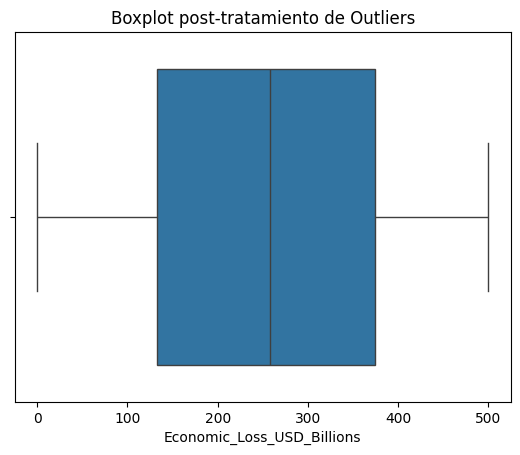

In [ ]:
col_outlier = 'Economic_Loss_USD_Billions'
Q1 = df[col_outlier].quantile(0.25)
Q3 = df[col_outlier].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

# Aplicación de Capping
df[col_outlier] = np.where(df[col_outlier] > limite_superior, limite_superior, df[col_outlier])

print(f"Límite superior calculado: {limite_superior}")
sns.boxplot(x=df[col_outlier])
plt.title("Boxplot post-tratamiento de Outliers")
plt.show()

#**Interpretación:**
- El gráfico de cajas (boxplot) nos permite observar visualmente la dispersión de los datos y los puntos que se alejan de los bigotes (outliers).
- Aplicamos el cálculo matemático del IQR para fijar límites técnicos y, en lugar de borrar esas filas (lo que causaría pérdida de información valiosa), decidimos "capear" (limitar) esos valores a los rangos máximos y mínimos aceptables.


#**Preprocesamiento: Encoding y Escalamiento Justificación:**
- transformaremos variables categóricas clave en números (Encoding). Además, como nuestras variables numéricas tienen unidades y rangos muy dispares, aplicaremos un escalamiento (MinMaxScaler) para llevar todas las magnitudes al rango de 0 a 1, tal como requiere la distancia euclidiana.

In [ ]:
# Label Encoding
le = LabelEncoder()
columnas_cat = ['Conflict_Type', 'Terrain_Type', 'Climate_Zone']
for col in columnas_cat:
    df[col + '_Encoded'] = le.fit_transform(df[col])

# Escalamiento Min-Max
scaler = MinMaxScaler()
columnas_num = ['Civilian_Deaths', 'Military_Deaths_A', 'Military_Deaths_B', 'Economic_Loss_USD_Billions']
df[columnas_num] = scaler.fit_transform(df[columnas_num])

print("Transformación completada con éxito.")
display(df.head())

Transformación completada con éxito.


,Country_A,Country_B,Conflict_Type,Year,Duration_Days,Military_Deaths_A,Military_Deaths_B,Civilian_Deaths,Economic_Loss_USD_Billions,Temperature_Avg_C,...,Ceasefire,Outcome,Latitude,Longitude,Climate_Zone,Resource_Dispute,UN_Involvement,Conflict_Type_Encoded,Terrain_Type_Encoded,Climate_Zone_Encoded
0,France,France,Cold Conflict,2020,1829,0.663299,0.825818,0.251601,0.352630,8.2,...,No,Victory_A,88.811,101.020,Temperate,Land,Yes,1,0,2
1,India,Japan,Cold Conflict,2013,1234,0.534536,0.208670,0.884314,0.871671,24.8,...,Yes,Stalemate,55.878,78.502,Polar,Water,No,1,3,1
2,Israel,USA,Civil War,1970,1982,0.343776,0.150081,0.086101,0.308707,17.3,...,No,Stalemate,29.263,144.680,Tropical,Water,No,0,2,3
3,Turkey,Australia,Proxy War,2021,1754,0.032872,0.668678,0.461276,0.546235,12.3,...,No,Victory_A,-22.281,-147.397,Polar,Water,No,2,3,1
4,Australia,France,War,2012,753,0.582161,0.813125,0.362559,0.702619,31.1,...,No,Victory_A,17.638,169.360,Temperate,Land,No,4,3,2


#**Interpretación:**


#**Análisis de Correlación Bi-variada Justificación:**
- Finalmente, generaremos un análisis de correlación utilizando el Coeficiente de Pearson. Trazaremos un Mapa de Calor (Heatmap) con la librería seaborn para identificar rápidamente relaciones lineales fuertes (positivas o negativas) entre nuestras variables numéricas, lo cual es fundamental para seleccionar los mejores atributos (Features) antes del modelamiento predictivo.

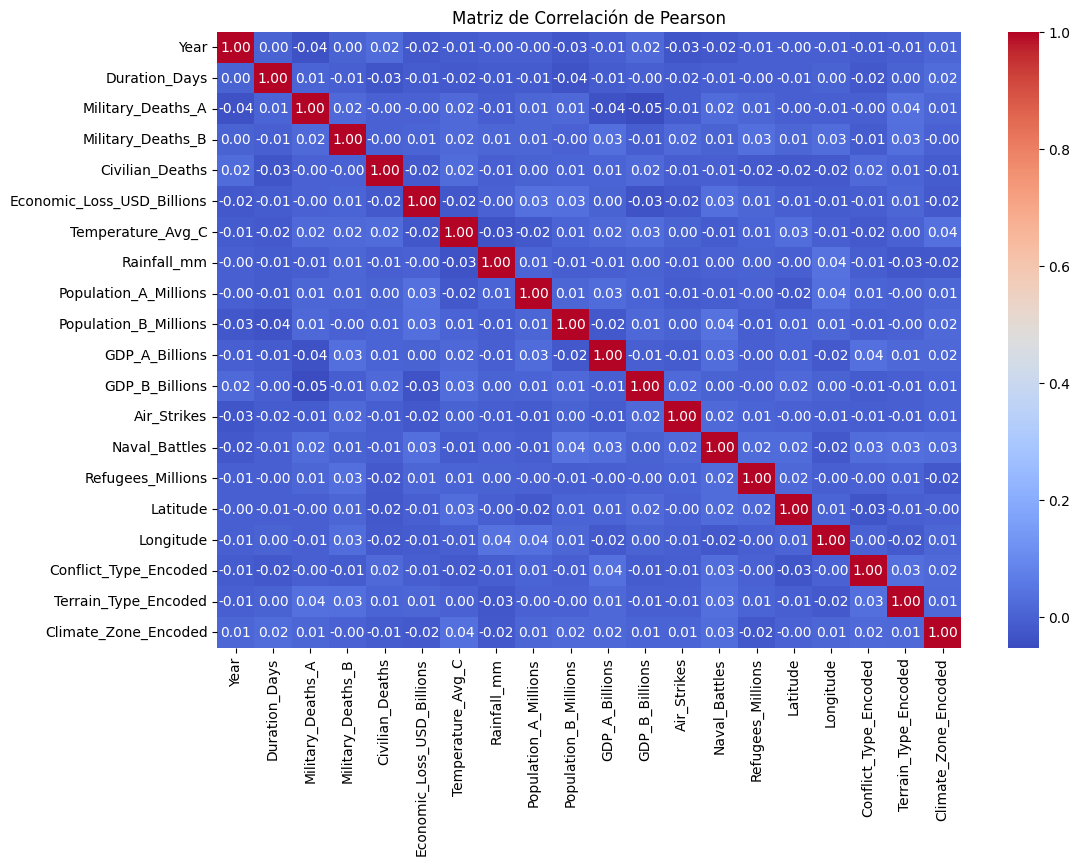

Correlación con Civilian_Deaths:
Civilian_Deaths               1.000000
Temperature_Avg_C             0.023636
Year                          0.023136
GDP_B_Billions                0.018493
Conflict_Type_Encoded         0.018206
Population_B_Millions         0.008741
Terrain_Type_Encoded          0.006937
GDP_A_Billions                0.006287
Population_A_Millions         0.004919
Military_Deaths_A            -0.000142
Military_Deaths_B            -0.001135
Rainfall_mm                  -0.005112
Naval_Battles                -0.005792
Air_Strikes                  -0.010637
Climate_Zone_Encoded         -0.011852
Longitude                    -0.015171
Refugees_Millions            -0.015583
Economic_Loss_USD_Billions   -0.017838
Latitude                     -0.022198
Duration_Days                -0.028468
Name: Civilian_Deaths, dtype: float64


In [ ]:
plt.figure(figsize=(12, 8))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación de Pearson")
plt.show()

# Aislamiento de impacto en muertes civiles
print("Correlación con Civilian_Deaths:")
print(corr_matrix['Civilian_Deaths'].sort_values(ascending=False))

#**Interpretación:**
- El mapa de calor nos entrega una visualización de las interacciones en todo el ecosistema de variables. Los tonos rojos intensos indicarán una correlación positiva fuerte (si una variable sube, la otra también), mientras que los tonos azules oscuros indicarán correlación negativa.
****
- La tabla impresa abajo del gráfico nos permite aislar el análisis. Por ejemplo, al revisar la correlación con Civilian_Deaths, podemos ver qué factores estadísticos (como cantidad de ataques aéreos o duración del conflicto) tienen la mayor fuerza de asociación lineal (valores más cercanos a 1).
- Si encontramos valores cercanos a 0, significaría que la estadística inferencial no detecta relación lineal aparente entre esos atributos puntuales.

#**Conclusiones (entrega 1)**
###
- Se logró limpiar y transformar el dataset de conflictos sin pérdida de registros.
- El tratamiento de outliers permitió estabilizar la variable económica.


****

#**ENTREGA 2**

Asignatura: Minería de Datos

Caso de Estudio: Dataset de Conflictos Globales

Integrantes: Eithan Santibañez, Matias morales

##**1. SELECCIÓN DE MODELOS**

- Regresión Lineal Múltiple: Dirigido a la predicción de variables numéricas continuas.

- Árbol de Decisión (Clasificación): Dirigido a la asignación de categorías o etiquetas discretas.

----

###Descarte de Naive Bayes (Modelos Bayesianos)

- Se evaluó la incorporación de un clasificador basado en el Teorema de Bayes, pero fue descartado debido a las siguientes restricciones teóricas y prácticas:
----
1. Violación del supuesto de independencia:
Naive Bayes asume independencia entre variables predictoras, supuesto inválido en este caso, ya que GDP, gasto militar y población presentan alta correlación. Ignorar estas dependencias reduce la precisión y el rigor estadístico del modelo

2. Manejo ineficiente de tipos de datos mixtos:
Naive Bayes presenta menor robustez frente a variables numéricas y categóricas combinadas, mientras que los Árboles de Decisión segmentan y jerarquizan estos atributos de forma más eficiente e interpretable.
----




##**2. JUSTIFICACIÓN TÉCNICA DE LOS MODELOS ELEGIDOS**

1. Justificación de Regresión Lineal Múltiple: Dado que Economic_Loss_USD_Billions es una variable continua, la Regresión Lineal Múltiple permite modelar el efecto simultáneo de múltiples predictores (Duration_Days, Population_A_Millions y GDP_A_Billions), cuantificando el impacto individual de cada variable mediante sus coeficientes
----
2. Justificación del Árbol de Decisión: El problema corresponde a una clasificación multiclase (Victoria A, Victoria B o Empate). Los Árboles de Decisión generan particiones jerárquicas mediante reglas lógicas, manejando eficazmente patrones no lineales sin requerir normalización de variables.

##**3. Codigo de implementación**

1. Importación de Librerías y Carga de Datos

In [ ]:
#Cargar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [ ]:
# cargar data
df_conflictos = pd.read_csv("/content/global_conflicts_dataset.csv")

2. Implementacion - modelo 1 Regresion lineal Multiple

In [ ]:
#1 Selección de variables y tratamiento de valores nulos
df_reg = df_conflictos[['Duration_Days', 'Population_A_Millions', 'GDP_A_Billions', 'Economic_Loss_USD_Billions']].dropna()
X_reg = df_reg[['Duration_Days', 'Population_A_Millions', 'GDP_A_Billions']]
y_reg = df_reg['Economic_Loss_USD_Billions']

In [ ]:
#2 División de datos en Entrenamiento (80%) y Prueba (20%)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [ ]:
#3 Construcción y ajuste (entrenamiento) del modelo paramétrico
modelo_reg = LinearRegression()
modelo_reg.fit(X_train_r, y_train_r)

LinearRegression()

In [ ]:
#4 Predicción y Cálculo de Métricas de Rendimiento
y_pred_r = modelo_reg.predict(X_test_r)
mse = mean_squared_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)

In [ ]:
#5 Despliegue de resultados en consola
print(" Resultados: Regresion Multiple")
print("="*50)
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")
print("-"*50)

 Resultados: Regresion Multiple
Error Cuadrático Medio (MSE): 19345.34
Coeficiente de Determinación (R²): -0.0071
--------------------------------------------------


###**Interpretacion:**

El modelo obtuvo un $R^2$ de $-0.0071$, indicando ausencia de relación lineal significativa entre las variables independientes seleccionadas (Duration_Days, Population_A_Millions y GDP_A_Billions) no tienen ninguna relación lineal con las pérdidas económicas (Economic_Loss_USD_Billions). Además, el alto MSE=19345.34 evidencia un error predictivo elevado, por lo que el modelo resulta menos preciso que una predicción basada únicamente en el promedio





3. Implementacion - Modelo 2 Árbol de decisión (clasificacion)

In [ ]:
#1 Preparación de datos y aislamiento de atributos predictivos
df_tree = df_conflictos[['Duration_Days', 'GDP_A_Billions', 'GDP_B_Billions', 'Outcome']].dropna()

# Preprocesamiento crítico: Conversión de categorías nominales a números secuenciales
le = LabelEncoder()
df_tree['Outcome_n'] = le.fit_transform(df_tree['Outcome'])

X_tree = df_tree[['Duration_Days', 'GDP_A_Billions', 'GDP_B_Billions']]
y_tree = df_tree['Outcome_n']

In [ ]:
#2 División de datos (80/20) aplicando una semilla fija para reproducibilidad
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_tree, y_tree, test_size=0.2, random_state=42)

In [ ]:
#3 Inicialización del modelo con Poda Preventiva (max_depth=4)
modelo_arbol = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_arbol.fit(X_train_t, y_train_t)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
#4 Evaluación del rendimiento del clasificador
y_pred_t = modelo_arbol.predict(X_test_t)
accuracy = accuracy_score(y_test_t, y_pred_t)

In [ ]:
#5 Despliegue de resultados en consola
print(" Resultado: Arbol de decision")
print("="*50)
print(f"Exactitud Global del Modelo (Accuracy): {accuracy:.4f}")
print("\n[Reporte Detallado de Clasificacion]")
print(classification_report(y_test_t, y_pred_t, target_names=le.classes_))
print("-"*50)

 Resultado: Arbol de decision
Exactitud Global del Modelo (Accuracy): 0.3250

[Reporte Detallado de Clasificacion]
              precision    recall  f1-score   support

   Stalemate       0.21      0.03      0.06       210
   Victory_A       0.33      0.73      0.45       200
   Victory_B       0.35      0.22      0.27       190

    accuracy                           0.33       600
   macro avg       0.29      0.33      0.26       600
weighted avg       0.29      0.33      0.26       600

--------------------------------------------------


###**Interpretacion:**

El dataset presenta tres clases distribuidas de manera casi equitativa en el conjunto de prueba: Stalemate (210 casos), Victory_A (200 casos) y Victory_B (190 casos). Ante un escenario de tres opciones, una clasificación puramente aleatoria  acertaría el $33.3\%$ de las veces. Al obtener un Accuracy del $32.50\%$, concluimos que nuestro arbol de decision está rindiendo al nivel del azar
****

4. Visualización grafica de las reglas del Árbol

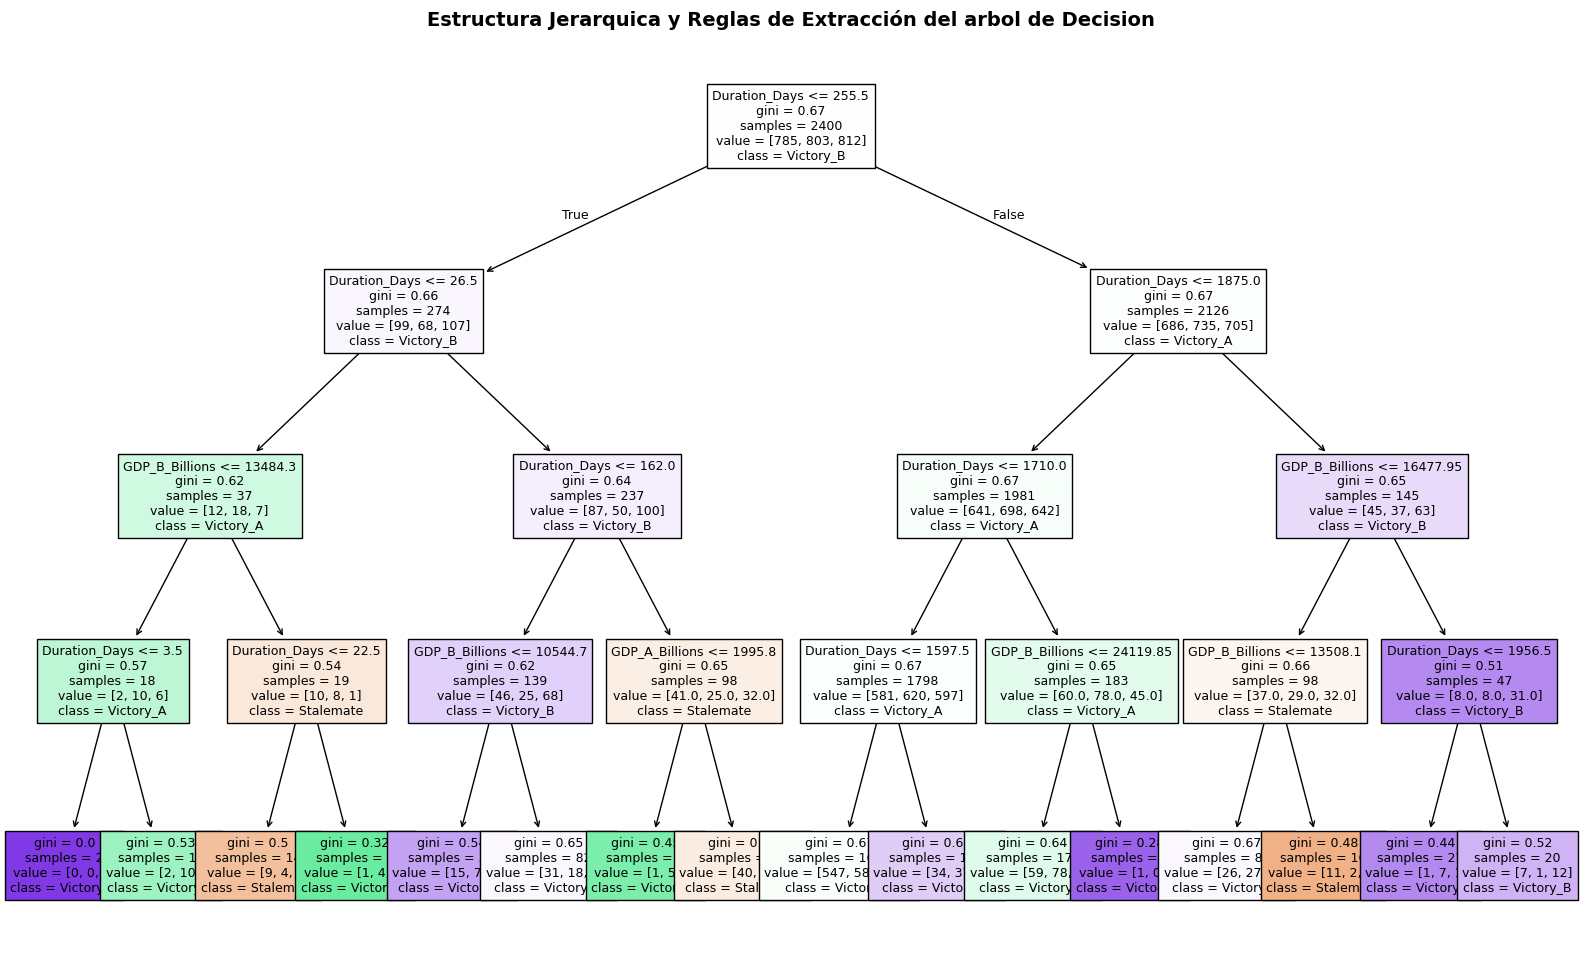

In [ ]:
# Extracción visual del patron jerarquico
plt.figure(figsize=(20,12))
plot_tree(
    modelo_arbol,
    feature_names=X_tree.columns,
    class_names=le.classes_,
    filled=True,
    fontsize=9,
    precision=2
)
plt.title("Estructura Jerarquica y Reglas de Extracción del arbol de Decision", fontsize=14, fontweight='bold')
plt.show()

###**interpretacion:**

Atributo Raíz Dominante: El modelo seleccionó la variable Duration_Days como el nodo principal de decisión.
****

Sesgo por sub-optimización: El arbol concentró la mayoría de las predicciones en la clase Victory_A, evidenciado por un Recall de 0.73 frente a 0.03 para Stalemate. Esto indica baja capacidad de discriminación y fronteras de decisión poco eficientes.